<div style="position:relative; width:100%; height:200px;">
  <img src="https://raw.githubusercontent.com/stefanlessmann/VHB_ProDoc_ML/master/banner-nb.png" style="width:100%; object-fit:cover;" alt="ProDok-MachineLearning-Banner">
  <div style="
      position:absolute;
      left:4%;
      top:50%;
      transform:translateY(-50%);
      font-size:3.2vw;
      font-weight:750;
      color:#1f2a44;">
    ProDok – Machine Learning
  </div>
</div>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/stefanlessmann/VHB_ProDoc_ML/blob/master/P.I.2.cs_benchmark_solution.ipynb)

# P.I.2 Machine Learning for Credit Risk Modeling: Model Selection, Evaluation, and Interpretation
The practice sessions complement the lectures and provide hands-on experience with the concepts covered in the course.
This session focuses on classic machine learning algorithms and practices. We will continue working with the credit risk analytics case, and benchmark alternative supervised learning algorithms to default prediction. In this scope, we will revisit data organization principles, classification model evaluation, and hyperparameter tuning. 

As in the previous practice session, the available time does not permit manual coding or extensive code reviews. We will provide coding demos for selected parts and otherwise rely on LLMs to generate the codes we need. The focus of the practice session is on prompt engineering and discussing ML outputs.  


# Data Preparation Reloaded

**Context:** 
We received a new sample of credit risk data. The sample comprises the same features and was taken 6 month after the first 100k batch was gathered. We developed Python codes to ready the data for analysis. However, the code was AI generated and not designed for reusability. Our first task is to *refactor* the data preparation code to ensure can use for the first and the second batch of data, as well as future batches yet to come. 

In [4]:
# Importing standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# We assume you stored the data locally. If not, use the URLs to load it from the web.
#url_100k = "https://raw.githubusercontent.com/stefanlessmann/VHB_ProDoc_ML/master/credit_data_100k.csv"
#url_25k = "https://raw.githubusercontent.com/stefanlessmann/VHB_ProDoc_ML/master/credit_data_25k.csv"

df_100 = pd.read_csv("credit_data_100k.csv")
df_25 = pd.read_csv("credit_data_25k.csv")

## Task: 
Use the code from `P.I.1.data_exploaration.ipynb` to create a reusable data preparation function. Apply your function to create *ready-for-modeling* versions of both datasets. Store the results in variables `dfDevelopment` and `dfHoldout`, respectively. 

In general, LLMs are good at refactoring code. Put our generated data preparation code into a prompt and instructing an LLM to refactor is should work just fine. One the other hand, all we need to do is wrapping up our previous code in a function. Decide freely if you want to approach the task by prompting an LLM or by coding the data preparation function yourself.

>Note that this exercise focuses on classification. Therefore, make sure to remove the `lgd` column from the data frames to prevent data leakage.




In [5]:
# Place for your data preparation function



In [6]:
# Place to call your function and creating modeling-ready datasets
dfDevelopment = None # Put your solution here
dfHoldout = None # Put your solution here

## SOLUTION

### Prompt for refactoring the data preparation code

### LLM-generated data preparation function (ChatGPT)


In [7]:
def prepare_credit_data(
    df: pd.DataFrame,
    winsor_limits=(0.01, 0.99),
    skew_threshold=1.0,
    add_missing_indicators=True,
    add_log_features=True,
    verbose=True
):
    """
    Prepare credit risk dataset for modeling.

    Parameters
    ----------
    df : pd.DataFrame
        Raw input dataframe following the defined data dictionary structure.
    winsor_limits : tuple(float, float)
        Lower/upper quantiles for winsorization of numeric predictors.
    skew_threshold : float
        Skewness threshold above which log1p features are added.
    add_missing_indicators : bool
        Whether to create missing indicator columns for numeric variables.
    add_log_features : bool
        Whether to create log1p features for skewed positive variables.
    verbose : bool
        Whether to print diagnostics.

    Returns
    -------
    dict with:
        df_model : modeling-ready dataframe (predictors + targets)
        predictors : list of predictor column names
        targets : list of target column names
        metadata : dict with preprocessing details
    """

    df_prep = df.copy(deep=True)

    # ---------------------------
    # 1) DEFINE ROLES
    # ---------------------------
    target_cols = ["default_12m", "lgd"]
    binary_cols = ["default_12m", "has_bank_account", "secured"]
    categorical_cols = ["employment_type", "housing_status", "region", "loan_purpose"]
    numeric_cols = [
        "age", "income", "years_at_job", "years_at_address",
        "loan_amount", "dti",
        "num_inquiries_6m", "num_delinquencies_24m",
        "num_collections", "card_utilization"
    ]

    present = set(df_prep.columns)
    target_cols = [c for c in target_cols if c in present]
    binary_cols = [c for c in binary_cols if c in present]
    categorical_cols = [c for c in categorical_cols if c in present]
    numeric_cols = [c for c in numeric_cols if c in present]

    # ---------------------------
    # 2) TYPE ENFORCEMENT
    # ---------------------------
    # Binary handling
    for c in binary_cols:
        if df_prep[c].dtype == "bool":
            df_prep[c] = df_prep[c].astype(int)

        if df_prep[c].dtype == "object":
            df_prep[c] = pd.to_numeric(df_prep[c], errors="coerce")

        df_prep[c] = pd.to_numeric(df_prep[c], errors="coerce")
        df_prep.loc[~df_prep[c].isin([0, 1]) & df_prep[c].notna(), c] = np.nan
        df_prep[c] = df_prep[c].astype("Int64")

    # Categorical
    for c in categorical_cols:
        df_prep[c] = df_prep[c].astype("category")

    # Numeric
    for c in numeric_cols:
        df_prep[c] = pd.to_numeric(df_prep[c], errors="coerce")

    # ---------------------------
    # 3) PLAUSIBILITY RULES
    # ---------------------------
    rules = {
        "age": lambda s: (s >= 18) & (s <= 100),
        "income": lambda s: s >= 0,
        "years_at_job": lambda s: s >= 0,
        "years_at_address": lambda s: s >= 0,
        "loan_amount": lambda s: s > 0,
        "dti": lambda s: (s >= 0) & (s <= 5),
        "num_inquiries_6m": lambda s: s >= 0,
        "num_delinquencies_24m": lambda s: s >= 0,
        "num_collections": lambda s: s >= 0,
        "card_utilization": lambda s: (s >= 0) & (s <= 2),
    }

    for col, rule in rules.items():
        if col in df_prep.columns:
            mask = df_prep[col].notna()
            df_prep.loc[mask & (~rule(df_prep[col])), col] = np.nan

    # ---------------------------
    # 4) MISSING VALUE HANDLING
    # ---------------------------
    excluded = set(target_cols)
    X_num = [c for c in numeric_cols if c not in excluded]
    X_cat = [c for c in categorical_cols if c not in excluded]
    X_bin = [c for c in binary_cols if c not in excluded and c != "default_12m"]

    num_missing_indicators = []

    # Numeric: median + optional missing indicator
    for c in X_num:
        if df_prep[c].isna().any():
            if add_missing_indicators:
                ind = f"{c}__missing"
                df_prep[ind] = df_prep[c].isna().astype(int)
                num_missing_indicators.append(ind)
            median = df_prep[c].median(skipna=True)
            df_prep[c] = df_prep[c].fillna(median)

    # Categorical: add explicit "missing"
    for c in X_cat:
        if df_prep[c].isna().any():
            df_prep[c] = df_prep[c].cat.add_categories(["missing"]).fillna("missing")

    # Binary: mode imputation
    for c in X_bin:
        if df_prep[c].isna().any():
            mode = df_prep[c].mode(dropna=True)
            fill = int(mode.iloc[0]) if len(mode) > 0 else 0
            df_prep[c] = df_prep[c].fillna(fill).astype(int)

    # ---------------------------
    # 5) WINSORIZATION
    # ---------------------------
    winsor_info = []
    for c in X_num:
        if df_prep[c].notna().sum() >= 30:
            lo = df_prep[c].quantile(winsor_limits[0])
            hi = df_prep[c].quantile(winsor_limits[1])
            df_prep[c] = df_prep[c].clip(lo, hi)
            winsor_info.append((c, lo, hi))

    # ---------------------------
    # 6) OPTIONAL LOG FEATURES
    # ---------------------------
    skewed_added = []
    log_features = []

    if add_log_features:
        for c in ["income", "loan_amount"]:
            if c in X_num and (df_prep[c] > 0).all():
                skew = df_prep[c].skew()
                if pd.notna(skew) and skew > skew_threshold:
                    newc = f"log1p_{c}"
                    df_prep[newc] = np.log1p(df_prep[c])
                    log_features.append(newc)
                    skewed_added.append((c, float(skew)))

    # ---------------------------
    # 7) ONE-HOT ENCODING
    # ---------------------------
    df_X = df_prep[X_num + X_bin + num_missing_indicators + log_features].copy()

    if X_cat:
        df_cat = pd.get_dummies(df_prep[X_cat], drop_first=True, dtype=int)
        df_X = pd.concat([df_X, df_cat], axis=1)

    # ---------------------------
    # 8) FINAL ASSEMBLY
    # ---------------------------
    df_model = df_X.copy()

    for t in target_cols:
        df_model[t] = df_prep[t]

    # Final predictor check
    predictor_cols = df_X.columns.tolist()
    if df_model[predictor_cols].isna().any().any():
        raise ValueError("Missing values remain in predictors after preprocessing.")

    if verbose:
        print("Data preparation complete.")
        print(f"Rows: {df.shape[0]}")
        print(f"Predictors: {len(predictor_cols)}")
        print(f"Targets: {target_cols}")

    metadata = {
        "numeric_predictors": X_num,
        "categorical_predictors": X_cat,
        "binary_predictors": X_bin,
        "missing_indicators": num_missing_indicators,
        "winsorization": winsor_info,
        "log_features": log_features,
    }

    return {
        "df_model": df_model,
        "predictors": predictor_cols,
        "targets": target_cols,
        "metadata": metadata
    }

In [8]:
# Place to call your function and creating modeling-ready datasets
print("\nPreparing training dataset...")
dpp100 = dfTrain = prepare_credit_data(df_100)
dfDevelopment = dpp100["df_model"]
dfDevelopment.drop(columns=["lgd"], inplace=True)  # Remove LGD to prevent data leakage

print("\nPreparing holdout dataset...")
dpp25 = dfTrain = prepare_credit_data(df_25)
dfHoldout = dpp25["df_model"]
dfHoldout.drop(columns=["lgd"], inplace=True)



Preparing training dataset...
Data preparation complete.
Rows: 100000
Predictors: 31
Targets: ['default_12m', 'lgd']

Preparing holdout dataset...
Data preparation complete.
Rows: 25000
Predictors: 31
Targets: ['default_12m', 'lgd']


# Overfitting demonstrated
The lecture introduced you to the *fundamental problem of overfitting*, claiming that decision trees are particularly vulnerable to overfitting to make a case for tree pruning. 

<p align="center">
  <img src="https://raw.githubusercontent.com/Humboldt-WI/demopy/main/tree_pruning.png" alt="Overfitting in decision trees" width="480">
</p>

## Task:

Verify the illustrated relationship between tree depth and overfitting. To that end, your task is to:
1. Partition the data of `dfDevelopment` into a training and validation set using ratios of 80%/20%.
2. Train a decision tree classifier on the training data with varying tree depth (e.g., from 1 to 10).
3. Evaluate the performance of each model on both the training and validation sets using an appropriate metric.
4. Plot the training and validation performance against tree depth to visualize the overfitting phenomenon.

The coding tasks asks for a basic ML pipeline involving functions/classes `train_test_split`, `DecisionTreeClassifier`, amongst others. It is a good exercise to code the solution yourself, but you can also use AI; a lazy prompt should do, no discussion of a prompting strategy warranted.

In [9]:
# Place for your solution

## SOLUTION

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Data organization and partitioning
froze_seed = 1803
y = dfDevelopment["default_12m"]
X = dfDevelopment.drop(columns=["default_12m"])  
Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=0.2, random_state=froze_seed)

# Variables to govern the experiment
train_perf = []
val_perf = []
tree_depths = list(range(1, 21))

# Model training and evaluation loop
for i, depth in enumerate(tree_depths):
    print(f"Training Decision Tree {i} of {len(tree_depths)} with max_depth={depth}...")
    model = DecisionTreeClassifier(max_depth=depth, random_state=froze_seed)
    model.fit(Xtrain, ytrain)

    train_score = 1 - model.score(Xtrain, ytrain)  # .score() returns accuracy, so 1 - accuracy gives error rate
    val_score = 1 - model.score(Xval, yval)

    train_perf.append(train_score)
    val_perf.append(val_score)

Training Decision Tree 0 of 20 with max_depth=1...
Training Decision Tree 1 of 20 with max_depth=2...
Training Decision Tree 2 of 20 with max_depth=3...
Training Decision Tree 3 of 20 with max_depth=4...
Training Decision Tree 4 of 20 with max_depth=5...
Training Decision Tree 5 of 20 with max_depth=6...
Training Decision Tree 6 of 20 with max_depth=7...
Training Decision Tree 7 of 20 with max_depth=8...
Training Decision Tree 8 of 20 with max_depth=9...
Training Decision Tree 9 of 20 with max_depth=10...
Training Decision Tree 10 of 20 with max_depth=11...
Training Decision Tree 11 of 20 with max_depth=12...
Training Decision Tree 12 of 20 with max_depth=13...
Training Decision Tree 13 of 20 with max_depth=14...
Training Decision Tree 14 of 20 with max_depth=15...
Training Decision Tree 15 of 20 with max_depth=16...
Training Decision Tree 16 of 20 with max_depth=17...
Training Decision Tree 17 of 20 with max_depth=18...
Training Decision Tree 18 of 20 with max_depth=19...
Training Dec

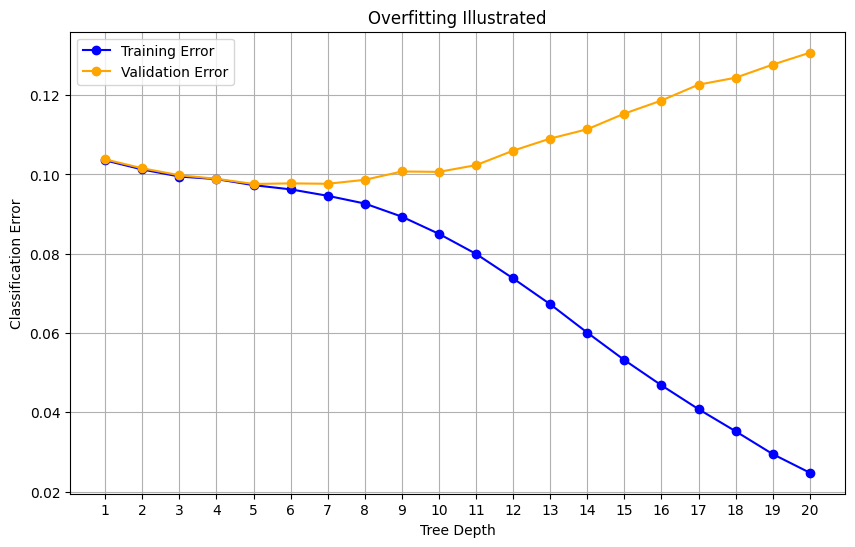

In [11]:

# Performance visualization
plt.figure(figsize=(10, 6))
plt.plot(tree_depths, train_perf, marker="o", c="blue", label="Training Error")
plt.plot(tree_depths, val_perf, marker="o", c="orange", label="Validation Error")
plt.title("Overfitting Illustrated")
plt.xlabel("Tree Depth")
plt.ylabel("Classification Error")
plt.xticks(tree_depths)
plt.grid()
plt.legend()
plt.show()

# Benchmarking
We finally hit the main part of the practice session: benchmarking different machine learning algorithms for credit risk modeling. This exercises addresses a common questions in machine learning applications: *which algorithm is best suited for my data?*
Research papers that introduce novel methodologies also include benchmarking exercises to demonstrate the superiority of their method. Lastly, a learning goal of this exercise is to familiarize you with standard machine learning workflows and relevant Python functions/classes. 

We frame the benchmarking task such that it is realistic and perhaps a bit challenging. We discuss details in class, including our prompting strategy for the coding part. 

## Task: 
Compare several established machine learning algorithms using the development sample (i.e., `dfDevelopment`). Consider logistic regression (LR), neural networks (NN), decision trees (DT), random forests (RF), and extreme gradient boosting (XGB). For algorithms that exhibit hyperparameters, make sure these are properly tuned. Assess the performance of the different algorithms in terms of i) the area under the ROC curve, ii) the area under the prediction-recall curve, iii) the F-score, and iv) the Brier score (i.e., the mean squared error of the predicted probabilities compared to a zero-one coded target). Produce an estimate of model performance for each algorithm on a suitably selected subset of the development data. Also assess models on the holdout data (i.e., `dfHoldout`). Plot the ROC-curve, the PR-curve, and the confusion matrix for logistic regression and the overall best-performing model (if different) on the holdout sample.  

In [12]:
# Place for your benchmarking code

## SOLUTION

### First-level prompt 
Given the task is complex, we considered a multi-level prompting strategy. The first prompt is a *lazy prompt* instructing an LLM to generate a suitable prompt given the exercise task. We would then proceed by using that first-level prompt to obtain a comprehensive second-level prompt, which eventually instructs the LLM to generate Python code. 

### LLM generated prompt in response to the first-level prompt (ChatGPT 5.2)

### LLM-generated benchmarking code in response to the second-level prompt (ChatGPT 5.2)
The first response of the LLM to our request for a benchmarking code was very comprehensive, but also very expensive to execute.  We had to ask the LLM to revise the code to reduce the computational cost of the experiment. We deliberately leave our first approach to prompt an LLM in the solution section to illustrate how LLMs can be used to generate code for complex tasks, but also complex task typically require either an iterative approach, like the one we took to arrive at the below *satisfactory* solution, or a more sophisticated prompting strategy, such as those discussed in yesterday's practice session. 

=== Data summary ===
Development (original): n=100,000, p=31, event_rate=0.1184
Development reduction disabled (r_percent=0).
Holdout: n=25,000, p=31, event_rate=0.1510

=== Tuning on development (Stratified CV) ===

-- LR -- (n_iter=10, cv_splits=3)
Best roc_auc (CV): 0.8108
Holdout: ROC-AUC=0.7993 | PR-AUC=0.5460 | F1=0.3238 | Brier=0.0981

-- NN -- (n_iter=12, cv_splits=3)
Best roc_auc (CV): 0.8442
Holdout: ROC-AUC=0.8307 | PR-AUC=0.5898 | F1=0.4169 | Brier=0.0929

-- DT -- (n_iter=12, cv_splits=3)
Best roc_auc (CV): 0.8212
Holdout: ROC-AUC=0.8074 | PR-AUC=0.5211 | F1=0.3673 | Brier=0.0981

-- RF -- (n_iter=8, cv_splits=3)
Best roc_auc (CV): 0.8393
Holdout: ROC-AUC=0.8285 | PR-AUC=0.5851 | F1=0.3560 | Brier=0.0939

-- XGB -- (n_iter=12, cv_splits=3)
Best roc_auc (CV): 0.8475
Holdout: ROC-AUC=0.8360 | PR-AUC=0.5963 | F1=0.4006 | Brier=0.0920

=== Results (sorted by holdout ROC-AUC) ===


,model,dev_cv_primary,dev_fit_roc_auc,dev_fit_pr_auc,dev_fit_f1,dev_fit_brier,hold_roc_auc,hold_pr_auc,hold_f1,hold_brier
0,XGB,0.847484,0.853875,0.590567,0.467415,0.071281,0.836027,0.596330,0.400638,0.092012
1,NN,0.844179,0.853386,0.587995,0.474421,0.071524,0.830719,0.589770,0.416861,0.092888
2,RF,0.839262,0.981346,0.872899,0.567125,0.047628,0.828493,0.585130,0.355982,0.093937
3,DT,0.821154,0.824195,0.508074,0.418144,0.077001,0.807407,0.521136,0.367322,0.098082
4,LR,0.810830,0.811236,0.520769,0.378068,0.079075,0.799284,0.546038,0.323773,0.098117



Best model by holdout ROC-AUC: XGB

=== Best hyperparameters ===

XGB best_params:
{'model__subsample': 0.7, 'model__reg_lambda': 10.0, 'model__n_estimators': 400, 'model__min_child_weight': 10, 'model__max_depth': 2, 'model__learning_rate': 0.1, 'model__gamma': 1.0, 'model__colsample_bytree': 0.9}

NN best_params:
{'model__learning_rate_init': np.float64(0.001), 'model__hidden_layer_sizes': (30, 20), 'model__alpha': np.float64(0.000630957344480193), 'model__activation': 'tanh'}

RF best_params:
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': None}

DT best_params:
{'model__min_samples_split': 20, 'model__min_samples_leaf': 10, 'model__max_depth': 12, 'model__ccp_alpha': 0.0001}

LR best_params:
{'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': np.float64(0.003511191734215131)}

=== Plots on holdout: ROC + PR ===


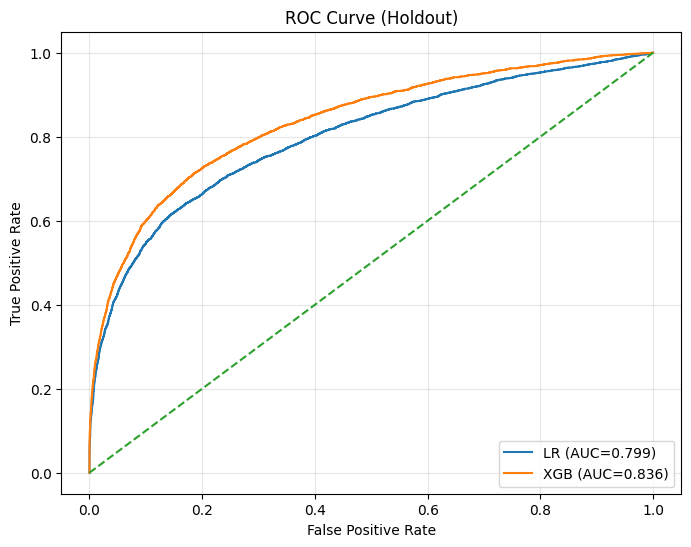

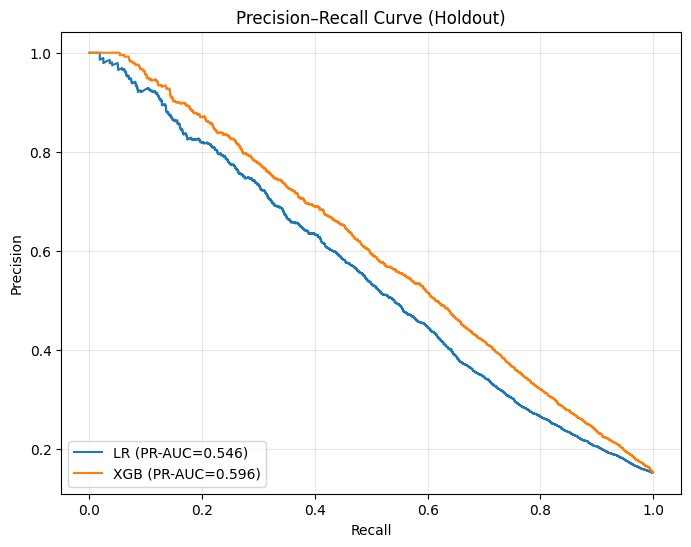


=== Confusion matrices on holdout ===


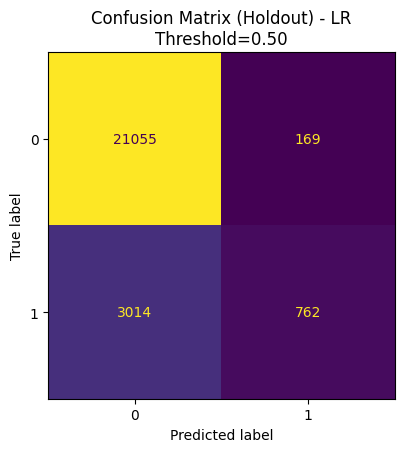

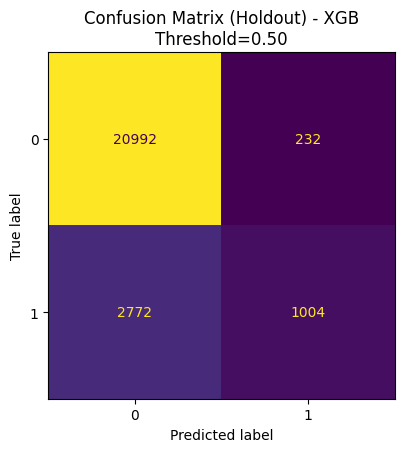

In [13]:
# ============================================================
# Credit Risk Benchmark (Resource-Aware)
# - Configurable via ExperimentConfig dataclass (single place to adjust)
# - Optional stratified downsampling of development set by r_percent
# - Models: LR, NN(MLP), DT, RF, XGB
# - Tuning: RandomizedSearchCV with StratifiedKFold
# - Metrics: ROC-AUC, PR-AUC, F1, Brier (dev-fit + holdout)
# - Plots (holdout): ROC, PR, confusion matrices for LR + best model
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass, field
from typing import Dict, Any, Tuple, Optional

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

import xgboost as xgb


# ---------------------------
# 1) Configuration
# ---------------------------
@dataclass
class ExperimentConfig:
    # Data
    target: str = "default_12m"
    r_percent: float = 0.0  # Reduce development data by r percent (stratified). Example: 80 => keep 20%.
    random_state: int = 1803

    # Evaluation / tuning
    cv_splits: int = 3
    primary_scoring: str = "roc_auc"   # model selection criterion
    threshold: float = 0.5             # fixed threshold for confusion matrix and F1

    # Search budget
    n_iter_default: int = 12
    n_iter_by_model: Dict[str, int] = field(default_factory=lambda: {
        "LR": 10,
        "NN": 12,
        "DT": 12,
        "RF": 8,     # RF is expensive; keep small
        "XGB": 12,
    })

    # Runtime safety toggles
    enable_models: Dict[str, bool] = field(default_factory=lambda: {
        "LR": True,
        "NN": True,
        "DT": True,
        "RF": True,
        "XGB": True,
    })

    # Model hyperparameter search spaces (ALL edits here)
    # Note: keys must match pipeline parameter names.
    # For pipeline: ("imputer" -> optional "scaler" -> "model")
    search_spaces: Dict[str, Any] = field(default_factory=lambda: {
        "LR": {
            "model__solver": ["liblinear"],
            "model__penalty": ["l1", "l2"],
            "model__C": np.logspace(-3, 3, 12),
        },
        "NN": {
            "model__hidden_layer_sizes": [(30,), (30,20)],
            "model__alpha": np.logspace(-5, -2, 6),
            "model__learning_rate_init": np.logspace(-4, -2, 5),
            "model__activation": ["relu", "tanh"],
        },
        "DT": {
            "model__max_depth": [None, 4, 8, 12],
            "model__min_samples_split": [2, 10, 20],
            "model__min_samples_leaf": [1, 5, 10],
            "model__ccp_alpha": [0.0, 1e-6, 1e-4, 1e-3],
        },
        "RF": {
            # IMPORTANT: RF is the usual runtime bottleneck; keep this tight.
            "model__n_estimators": [150, 300],
            "model__max_depth": [None, 6, 10],
            "model__min_samples_split": [2, 10],
            "model__min_samples_leaf": [1, 5],
            "model__max_features": ["sqrt", "log2"],
        },
        "XGB": {
            # XGB is usually faster than RF at this scale with tree_method='hist'
            "model__n_estimators": [200, 400],
            "model__max_depth": [2, 3, 4, 5],
            "model__learning_rate": [0.02, 0.05, 0.1],
            "model__subsample": [0.7, 0.9, 1.0],
            "model__colsample_bytree": [0.7, 0.9, 1.0],
            "model__min_child_weight": [1, 5, 10],
            "model__reg_lambda": [1.0, 5.0, 10.0],
            "model__gamma": [0.0, 0.5, 1.0],
        },
    })


# ---------------------------
# 2) Helper functions
# ---------------------------
def split_xy(df: pd.DataFrame, target: str) -> Tuple[pd.DataFrame, np.ndarray]:
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found.")
    X = df.drop(columns=[target])
    y = df[target].astype(int).values
    u = set(np.unique(y))
    if not u.issubset({0, 1}):
        raise ValueError(f"Target must be binary {{0,1}}. Found: {sorted(u)}")
    return X, y

def stratified_reduce(X: pd.DataFrame, y: np.ndarray, r_percent: float, random_state: int):
    """Reduce dataset size by r_percent (stratified). r_percent=80 keeps 20%."""
    if r_percent <= 0:
        return X, y
    if r_percent >= 99.9:
        raise ValueError("r_percent too large; would leave almost no data.")
    keep_frac = 1.0 - (r_percent / 100.0)

    rng = np.random.default_rng(random_state)
    idx = np.arange(len(y))
    idx0 = idx[y == 0]
    idx1 = idx[y == 1]

    n0 = max(1, int(round(len(idx0) * keep_frac)))
    n1 = max(1, int(round(len(idx1) * keep_frac)))

    keep0 = rng.choice(idx0, size=n0, replace=False)
    keep1 = rng.choice(idx1, size=n1, replace=False)
    keep = np.concatenate([keep0, keep1])
    rng.shuffle(keep)

    Xr = X.iloc[keep].copy()
    yr = y[keep].copy()
    return Xr, yr

def make_pipe(model, with_scaling: bool) -> Pipeline:
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if with_scaling:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", model))
    return Pipeline(steps=steps)

def compute_metrics(y_true: np.ndarray, proba: np.ndarray, threshold: float) -> Dict[str, float]:
    proba = np.asarray(proba).ravel()
    y_pred = (proba >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "brier": brier_score_loss(y_true, proba),
    }

def plot_roc_pr(y_true: np.ndarray, proba_by_model: Dict[str, np.ndarray], title_suffix: str = "(Holdout)"):
    # ROC
    plt.figure(figsize=(8, 6))
    for name, proba in proba_by_model.items():
        fpr, tpr, _ = roc_curve(y_true, proba)
        auc = roc_auc_score(y_true, proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve {title_suffix}")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

    # PR
    plt.figure(figsize=(8, 6))
    for name, proba in proba_by_model.items():
        prec, rec, _ = precision_recall_curve(y_true, proba)
        ap = average_precision_score(y_true, proba)
        plt.plot(rec, prec, label=f"{name} (PR-AUC={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve {title_suffix}")
    plt.legend(loc="lower left")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_confusion(y_true: np.ndarray, proba: np.ndarray, model_name: str, threshold: float):
    y_pred = (np.asarray(proba).ravel() >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"Confusion Matrix (Holdout) - {model_name}\nThreshold={threshold:.2f}")
    plt.grid(False)
    plt.show()


# ---------------------------
# 3) Build model registry
# ---------------------------
def build_models(cfg: ExperimentConfig) -> Dict[str, Tuple[Pipeline, Any]]:
    models = {}

    if cfg.enable_models.get("LR", True):
        lr = LogisticRegression(max_iter=3000, random_state=cfg.random_state)
        models["LR"] = (make_pipe(lr, with_scaling=True), cfg.search_spaces["LR"])

    if cfg.enable_models.get("NN", True):
        mlp = MLPClassifier(
            random_state=cfg.random_state,
            early_stopping=True,
            n_iter_no_change=10,
            max_iter=250
        )
        models["NN"] = (make_pipe(mlp, with_scaling=True), cfg.search_spaces["NN"])

    if cfg.enable_models.get("DT", True):
        dt = DecisionTreeClassifier(random_state=cfg.random_state)
        models["DT"] = (make_pipe(dt, with_scaling=False), cfg.search_spaces["DT"])

    if cfg.enable_models.get("RF", True):
        rf = RandomForestClassifier(
            random_state=cfg.random_state,
            n_jobs=-1,
            bootstrap=True
        )
        models["RF"] = (make_pipe(rf, with_scaling=False), cfg.search_spaces["RF"])

    if cfg.enable_models.get("XGB", True):
        xgb_clf = xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=cfg.random_state,
            n_jobs=-1,
            tree_method="hist",
            verbosity=0
        )
        models["XGB"] = (make_pipe(xgb_clf, with_scaling=False), cfg.search_spaces["XGB"])

    return models


# ---------------------------
# 4) Main experiment runner
# ---------------------------
def run_experiment(cfg: ExperimentConfig, dfDevelopment: pd.DataFrame, dfHoldout: pd.DataFrame):
    # Prepare data
    X_dev, y_dev = split_xy(dfDevelopment, cfg.target)
    X_hold, y_hold = split_xy(dfHoldout, cfg.target)

    # Optional reduction (stratified)
    X_dev_used, y_dev_used = stratified_reduce(X_dev, y_dev, cfg.r_percent, cfg.random_state)

    print("=== Data summary ===")
    print(f"Development (original): n={len(X_dev):,}, p={X_dev.shape[1]:,}, event_rate={y_dev.mean():.4f}")
    if cfg.r_percent > 0:
        print(f"Development (reduced by r={cfg.r_percent:.1f}%): n={len(X_dev_used):,}, p={X_dev_used.shape[1]:,}, event_rate={y_dev_used.mean():.4f}")
    else:
        print("Development reduction disabled (r_percent=0).")
    print(f"Holdout: n={len(X_hold):,}, p={X_hold.shape[1]:,}, event_rate={y_hold.mean():.4f}")

    # CV
    cv = StratifiedKFold(n_splits=cfg.cv_splits, shuffle=True, random_state=cfg.random_state)

    # Models
    model_specs = build_models(cfg)
    if not model_specs:
        raise ValueError("No models enabled. Set cfg.enable_models accordingly.")

    rows = []
    fitted_models = {}

    print("\n=== Tuning on development (Stratified CV) ===")
    for name, (pipe, space) in model_specs.items():
        n_iter = cfg.n_iter_by_model.get(name, cfg.n_iter_default)
        print(f"\n-- {name} -- (n_iter={n_iter}, cv_splits={cfg.cv_splits})")

        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=space,
            n_iter=n_iter,
            scoring=cfg.primary_scoring,
            cv=cv,
            n_jobs=-1,
            random_state=cfg.random_state,
            refit=True,
            verbose=0
        )

        # Fit on (possibly reduced) development
        search.fit(X_dev_used, y_dev_used)
        best_model = search.best_estimator_
        fitted_models[name] = best_model

        # Dev metrics (on used dev with refit model) — fast, slightly optimistic, but tuning is CV-based
        proba_dev = best_model.predict_proba(X_dev_used)[:, 1]
        m_dev = compute_metrics(y_dev_used, proba_dev, threshold=cfg.threshold)

        # Holdout metrics
        proba_hold = best_model.predict_proba(X_hold)[:, 1]
        m_hold = compute_metrics(y_hold, proba_hold, threshold=cfg.threshold)

        rows.append({
            "model": name,
            "dev_cv_primary": float(search.best_score_),
            "dev_fit_roc_auc": m_dev["roc_auc"],
            "dev_fit_pr_auc": m_dev["pr_auc"],
            "dev_fit_f1": m_dev["f1"],
            "dev_fit_brier": m_dev["brier"],
            "hold_roc_auc": m_hold["roc_auc"],
            "hold_pr_auc": m_hold["pr_auc"],
            "hold_f1": m_hold["f1"],
            "hold_brier": m_hold["brier"],
            "best_params": search.best_params_,
        })

        print(f"Best {cfg.primary_scoring} (CV): {search.best_score_:.4f}")
        print(f"Holdout: ROC-AUC={m_hold['roc_auc']:.4f} | PR-AUC={m_hold['pr_auc']:.4f} | F1={m_hold['f1']:.4f} | Brier={m_hold['brier']:.4f}")

    results = pd.DataFrame(rows).sort_values("hold_roc_auc", ascending=False).reset_index(drop=True)

    print("\n=== Results (sorted by holdout ROC-AUC) ===")
    display(results.drop(columns=["best_params"]))

    best_model_name = results.loc[0, "model"]
    print(f"\nBest model by holdout ROC-AUC: {best_model_name}")

    print("\n=== Best hyperparameters ===")
    for _, r in results.iterrows():
        print(f"\n{r['model']} best_params:")
        print(r["best_params"])

    # Plots: LR + best model (if different)
    if "LR" not in fitted_models:
        print("\nLR disabled; skipping LR plots.")
        plot_models = [best_model_name]
    else:
        plot_models = ["LR"] if best_model_name == "LR" else ["LR", best_model_name]

    proba_by_model = {}
    for mname in plot_models:
        proba_by_model[mname] = fitted_models[mname].predict_proba(X_hold)[:, 1]

    print("\n=== Plots on holdout: ROC + PR ===")
    plot_roc_pr(y_hold, proba_by_model, title_suffix="(Holdout)")

    print("\n=== Confusion matrices on holdout ===")
    for mname in plot_models:
        plot_confusion(y_hold, proba_by_model[mname], mname, threshold=cfg.threshold)

    return results, fitted_models


# ---------------------------
# 5) Run
# ---------------------------
cfg = ExperimentConfig(
    # Example: reduce development by 80% (keep 20%) for faster runs on limited resources:
    # r_percent=80.0
    r_percent=0.0
)

results, fitted_models = run_experiment(cfg, dfDevelopment, dfHoldout)

In [14]:
fitted_models

{'LR': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('model',
                  LogisticRegression(C=np.float64(0.003511191734215131),
                                     max_iter=3000, random_state=1803,
                                     solver='liblinear'))]),
 'NN': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('model',
                  MLPClassifier(activation='tanh',
                                alpha=np.float64(0.000630957344480193),
                                early_stopping=True, hidden_layer_sizes=(30, 20),
                                learning_rate_init=np.float64(0.001),
                                max_iter=250, random_state=1803))]),
 'DT': Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('model',
                  DecisionTreeClassifier(ccp_alpha=0.0001, max_dep